# Pole shape — data sanity check

Run this notebook from the **repository root** (so `data/images` resolves). In VS Code/Cursor: open the folder `pole-shape-classifer`, then run cells. Select the project interpreter: `.venv/bin/python`.

In [11]:
%matplotlib inline

from pathlib import Path

import keras
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from keras import layers
from keras.applications import EfficientNetB0

ROOT = Path.cwd()
IMAGE_DIR = ROOT / "data" / "images"
if not IMAGE_DIR.is_dir():
    raise FileNotFoundError(
        f"Missing {IMAGE_DIR}. cd to the repo root or fix IMAGE_DIR."
    )

In [2]:
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    IMAGE_DIR,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=(224, 224),
    batch_size=batch_size,
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 1903 files belonging to 2 classes.
Using 1523 files for training.
Using 380 files for validation.
Classes: ['inside_leg_hang', 'outside_leg_hang']


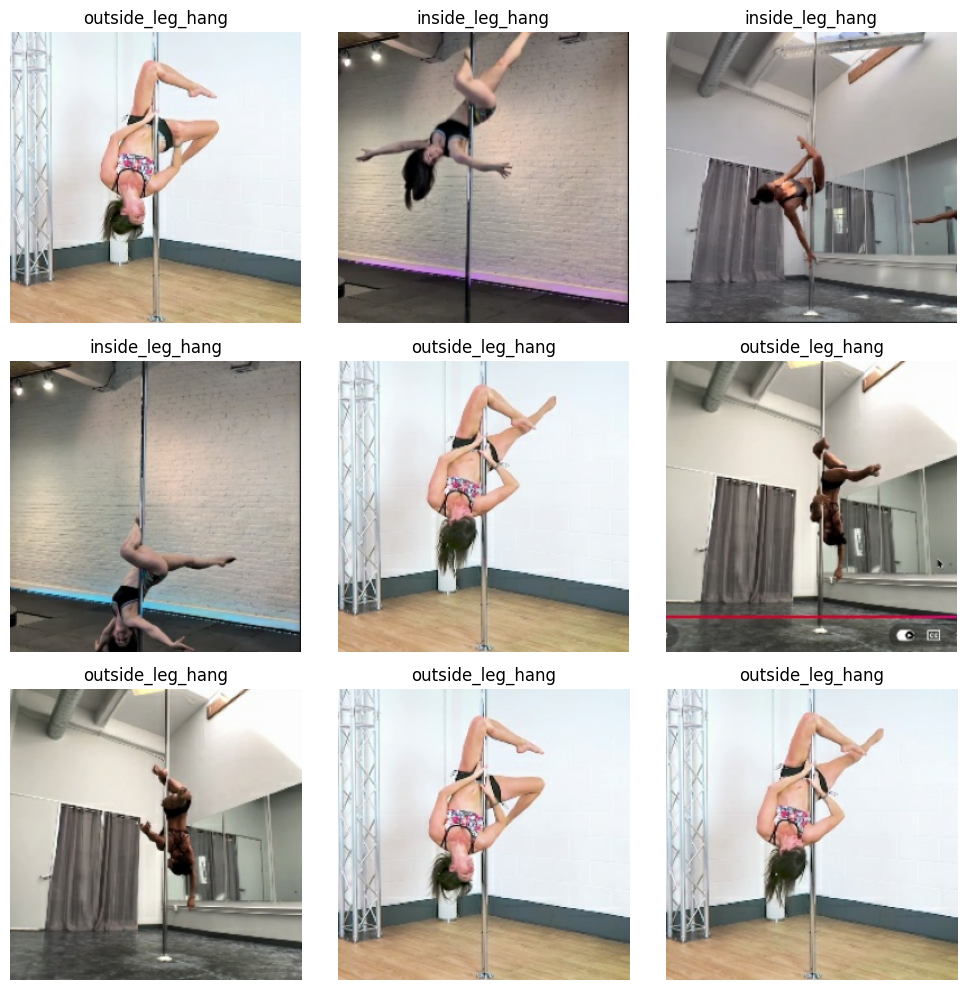

In [3]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    n = min(9, int(images.shape[0]))
    for i in range(n):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        lbl = int(labels[i])
        title = class_names[lbl] if lbl < len(class_names) else str(lbl)
        plt.title(title)
        plt.axis("off")
plt.tight_layout()
plt.show()

# Train baseline model - EfficientNetB0

In [ ]:
from keras.applications.efficientnet import preprocess_input


def prep(images, labels):
    return preprocess_input(tf.cast(images, tf.float32)), labels


# Preprocessed pipelines for training (keep raw train_ds / val_ds for plotting above)
train_ds_model = train_ds.map(prep, num_parallel_calls=tf.data.AUTOTUNE).prefetch(
    tf.data.AUTOTUNE
)
val_ds_model = val_ds.map(prep, num_parallel_calls=tf.data.AUTOTUNE).prefetch(
    tf.data.AUTOTUNE
)


In [ ]:
num_classes = len(class_names)

base_model = EfficientNetB0(
    weights="imagenet", include_top=False, input_shape=(224, 224, 3)
)
base_model.trainable = False  # Freeze weights initially

model = tf.keras.Sequential(
    [
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ]
)

model.compile(
    optimizer="adam",
    # Labels are class indices (batch,); use sparse CE, not categorical (one-hot).
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history = model.fit(
    train_ds_model,
    validation_data=val_ds_model,
    epochs=5,
)


In [7]:
loss, acc = model.evaluate(val_ds_model)
print(f"val loss: {loss:.4f}, val acc: {acc:.4f}")


48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 244ms/step
